# Uplift Trees Example with Synthetic Data

In this notebook, we use synthetic data to demonstrate the use of the tree-based algorithms.

## Initialize environment

In [2]:
pip install causalml

In [3]:
import numpy as np
import pandas as pd

from causalml.dataset import make_uplift_classification
from causalml.inference.tree import UpliftRandomForestClassifier
from causalml.metrics import plot_gain,auuc_score

from sklearn.model_selection import train_test_split

ERROR:duecredit:Failed to import duecredit due to No module named 'duecredit'


In [4]:
import importlib
print(importlib.metadata.version('causalml') )

0.16.0


## Generate synthetic dataset

The CausalML package contains various functions to generate synthetic datasets for uplift modeling. Here we generate a classification dataset using the make_uplift_classification() function.

In [5]:
df, x_names = make_uplift_classification(treatment_name=['control', 'treatment1'])

In [6]:
df.head()

,treatment_group_key,x1_informative,x2_informative,x3_informative,x4_informative,x5_informative,x6_irrelevant,x7_irrelevant,x8_irrelevant,x9_irrelevant,x10_irrelevant,x11_uplift_increase,x12_uplift_increase,x13_increase_mix,conversion,treatment_effect
0,treatment1,-0.090262,2.212644,0.465246,1.234381,3.605371,0.263686,-1.391989,-0.748999,0.995666,-0.559627,-1.230003,-1.287073,0.965100,1,0
1,treatment1,1.296345,1.126756,-0.390840,2.816444,0.878906,-0.495582,0.105605,-2.181952,-0.904848,-0.718033,-1.460874,-0.784958,0.732743,1,0
2,control,-1.777419,-0.746741,-2.206541,-0.399638,3.986540,-1.138827,-0.765340,-0.113769,-1.411139,0.921662,1.321086,-0.938183,0.520914,0,0
3,control,-2.356745,-1.958517,-0.765114,3.736352,1.801522,1.317978,-1.095714,0.729767,2.489876,0.090676,0.817920,-2.100586,1.339432,0,0
4,control,0.111738,-1.506129,0.095115,0.068337,1.294267,-0.178877,-0.488089,0.257341,0.210113,2.235305,-1.338732,-2.291904,1.747627,1,0


In [7]:
x_names

['x1_informative',
 'x2_informative',
 'x3_informative',
 'x4_informative',
 'x5_informative',
 'x6_irrelevant',
 'x7_irrelevant',
 'x8_irrelevant',
 'x9_irrelevant',
 'x10_irrelevant',
 'x11_uplift_increase',
 'x12_uplift_increase',
 'x13_increase_mix']

In [8]:
# Look at the conversion rate and sample size in each group
df.pivot_table(values='conversion',
               index='treatment_group_key',
               aggfunc=[np.mean, np.size],
               margins=True)

,mean,size
,conversion,conversion
treatment_group_key,,
control,0.483,1000
treatment1,0.537,1000
All,0.510,2000


In [11]:
# Split data to training and testing samples for model validation (next section)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=111)

## Uplift XLearner

### ❌ XGBClassifier not working yet

In [9]:
'''
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from causalml.inference.meta import BaseXLearner
from causalml.dataset import make_uplift_classification

# 1. 準備數據：生成一個包含 1000 個樣本的 Uplift 合成數據集
# y: 轉換結果 (0 或 1), treatment: 分組標籤, X: 特徵
df, features = make_uplift_classification(n_samples=1000, treatment_name=['control', 'treatment'])
X = df[features].values
y = df['conversion'].values
treatment = df['treatment_group_key'].values

# 2. 初始化 BaseXLearner
# 這裡指定 XGBClassifier 作為底層 Learner
learner = BaseXLearner(learner=XGBClassifier(random_state=42),control_name='control')

# 3. 訓練模型
# X: 特徵矩陣, treatment: 治療組/對照組標籤, y: 目標變量
learner.fit(X=X, treatment=treatment, y=y)

# 4. 預測個體治療效應 (ITE / CATE)
# predict 會回傳每個樣本在「實驗組」相比「對照組」下的預期增量效應
cate_estimates = learner.predict(X=X)

# 5. 查看結果
print(f"前 5 個樣本的 CATE 估計值:\n{cate_estimates[:5]}")
'''

'\nimport pandas as pd\nimport numpy as np\nfrom xgboost import XGBClassifier\nfrom causalml.inference.meta import BaseXLearner\nfrom causalml.dataset import make_uplift_classification\n\n# 1. 準備數據：生成一個包含 1000 個樣本的 Uplift 合成數據集\n# y: 轉換結果 (0 或 1), treatment: 分組標籤, X: 特徵\ndf, features = make_uplift_classification(n_samples=1000, treatment_name=[\'control\', \'treatment\'])\nX = df[features].values\ny = df[\'conversion\'].values\ntreatment = df[\'treatment_group_key\'].values\n\n# 2. 初始化 BaseXLearner\n# 這裡指定 XGBClassifier 作為底層 Learner\nlearner = BaseXLearner(learner=XGBClassifier(random_state=42),control_name=\'control\')\n\n# 3. 訓練模型\n# X: 特徵矩陣, treatment: 治療組/對照組標籤, y: 目標變量\nlearner.fit(X=X, treatment=treatment, y=y)\n\n# 4. 預測個體治療效應 (ITE / CATE)\n# predict 會回傳每個樣本在「實驗組」相比「對照組」下的預期增量效應\ncate_estimates = learner.predict(X=X)\n\n# 5. 查看結果\nprint(f"前 5 個樣本的 CATE 估計值:\n{cate_estimates[:5]}")\n'

### LogisticsRegression Can work

In [12]:
from causalml.inference.meta import BaseXLearner
from sklearn.linear_model import LogisticRegression
learner = BaseXLearner(learner=LogisticRegression(),control_name='control')
learner.fit(df_train[x_names].values,
         treatment=df_train['treatment_group_key'].values,
         y=df_train['conversion'].values)
logistics_uplift_estimates = learner.predict(df_test[x_names].values)


## Run the uplift Tree classifier

In this section, we first fit the uplift random forest classifier using training data. We then use the fitted model to make a prediction using testing data. The prediction returns an ndarray in which each column contains the predicted uplift if the unit was in the corresponding treatment group.

In [13]:
x_names

['x1_informative',
 'x2_informative',
 'x3_informative',
 'x4_informative',
 'x5_informative',
 'x6_irrelevant',
 'x7_irrelevant',
 'x8_irrelevant',
 'x9_irrelevant',
 'x10_irrelevant',
 'x11_uplift_increase',
 'x12_uplift_increase',
 'x13_increase_mix']

In [14]:
from causalml.inference.tree import UpliftTreeClassifier

In [15]:
clf = UpliftTreeClassifier(control_name='control')
clf.fit(df_train[x_names].values,
         treatment=df_train['treatment_group_key'].values,
         y=df_train['conversion'].values)
p = clf.predict(df_test[x_names].values)

In [16]:
y_pred_tree = p

In [17]:
df_res = pd.DataFrame(p, columns=clf.classes_)
df_res.head()

,control,treatment1
0,0.425287,0.535792
1,0.634783,0.512000
2,0.425287,0.535792
3,0.634783,0.512000
4,0.634783,0.512000


## UpliftRandomForest

In [18]:
uplift_model = UpliftRandomForestClassifier(control_name='control')

In [19]:
uplift_model.fit(df_train[x_names].values,
                 treatment=df_train['treatment_group_key'].values,
                 y=df_train['conversion'].values)

In [20]:
df_res = uplift_model.predict(df_test[x_names].values, full_output=True)
print(df_res.shape)
df_res.head()

(400, 5)


,control,treatment1,recommended_treatment,delta_treatment1,max_delta
0,0.511844,0.466026,0,-0.045818,-0.045818
1,0.534518,0.563963,1,0.029445,0.029445
2,0.508903,0.413327,0,-0.095577,-0.095577
3,0.578797,0.554016,0,-0.024782,-0.024782
4,0.473534,0.618324,1,0.144790,0.144790


In [21]:
y_pred_forest = uplift_model.predict(df_test[x_names].values)

## Create the uplift curve

The performance of the model can be evaluated with the help of the [uplift curve](http://proceedings.mlr.press/v67/gutierrez17a/gutierrez17a.pdf).

## Create a synthetic population

The uplift curve is calculated on a synthetic population that consists of those that were in the control group and those who happened to be in the treatment group recommended by the model. We use the synthetic population to calculate the _actual_ treatment effect within _predicted_ treatment effect quantiles. Because the data is randomized, we have a roughly equal number of treatment and control observations in the predicted quantiles and there is no self selection to treatment groups.

In [23]:
'''
# If all deltas are negative, assing to control; otherwise assign to the treatment
# with the highest delta
best_treatment = np.where((result < 0).all(axis=1),
                           'control',
                           result.idxmax(axis=1))

# Create indicator variables for whether a unit happened to have the
# recommended treatment or was in the control group
actual_is_best = np.where(df_test['treatment_group_key'] == best_treatment, 1, 0)
actual_is_control = np.where(df_test['treatment_group_key'] == 'control', 1, 0)
'''

"\n# If all deltas are negative, assing to control; otherwise assign to the treatment\n# with the highest delta\nbest_treatment = np.where((result < 0).all(axis=1),\n                           'control',\n                           result.idxmax(axis=1))\n\n# Create indicator variables for whether a unit happened to have the\n# recommended treatment or was in the control group\nactual_is_best = np.where(df_test['treatment_group_key'] == best_treatment, 1, 0)\nactual_is_control = np.where(df_test['treatment_group_key'] == 'control', 1, 0)\n"

In [24]:
treatments = np.where((df_test['treatment_group_key']=='treatment1'), 1, 0)

In [27]:
'''
synthetic = (actual_is_best == 1) | (actual_is_control == 1)
synth = result[synthetic]
'''

'\nsynthetic = (actual_is_best == 1) | (actual_is_control == 1)\nsynth = result[synthetic]\n'

## Feature selection

In [28]:
from causalml.feature_selection.filters import FilterSelect
filter_method = FilterSelect()

In [29]:
y_name = 'conversion'
treatment_group_keys = ['control', 'treatment1']

In [30]:
method = 'KL'
kl_imp = filter_method.get_importance(df, x_names, y_name, method,
                      treatment_group = 'treatment1',
                      n_bins=10)
kl_imp.head()

,method,feature,rank,score,p_value,misc
0,KL filter,x3_informative,1.0,0.019039,None,number_of_bins: 10
0,KL filter,x11_uplift_increase,2.0,0.018859,None,number_of_bins: 10
0,KL filter,x1_informative,3.0,0.018296,None,number_of_bins: 10
0,KL filter,x13_increase_mix,4.0,0.012443,None,number_of_bins: 10
0,KL filter,x8_irrelevant,5.0,0.011743,None,number_of_bins: 10


In [31]:
top_n = 10
top_10_features = kl_imp['feature'][:top_n]
print(top_10_features)

0         x3_informative
0    x11_uplift_increase
0         x1_informative
0       x13_increase_mix
0          x8_irrelevant
0          x7_irrelevant
0          x9_irrelevant
0         x5_informative
0         x2_informative
0          x6_irrelevant
Name: feature, dtype: object


In [32]:
top_n = 15
top_15_features = kl_imp['feature'][:top_n]
print(top_15_features)

0         x3_informative
0    x11_uplift_increase
0         x1_informative
0       x13_increase_mix
0          x8_irrelevant
0          x7_irrelevant
0          x9_irrelevant
0         x5_informative
0         x2_informative
0          x6_irrelevant
0    x12_uplift_increase
0         x10_irrelevant
0         x4_informative
Name: feature, dtype: object


In [33]:
# using top 10 features
features = top_10_features

uplift_model.fit(X = df_train[features].values,
                 treatment = df_train['treatment_group_key'].values,
                 y = df_train[y_name].values)
y_preds_t10 = uplift_model.predict(df_test[features].values)

In [34]:
# using top 15 features
features = top_15_features

uplift_model.fit(X = df_train[features].values,
                 treatment = df_train['treatment_group_key'].values,
                 y = df_train[y_name].values)
y_preds_t15 = uplift_model.predict(df_test[features].values)

## Calculate the observed treatment effect per predicted treatment effect quantile

We use the observed treatment effect to calculate the uplift curve, which answers the question: how much of the total cumulative uplift could we have captured by targeting a subset of the population sorted according to the predicted uplift, from highest to lowest?

CausalML has the plot_gain() function which calculates the uplift curve given a DataFrame containing the treatment assignment, observed outcome and the predicted treatment effect.

In [36]:
'''
auuc_metrics = (synth.assign(is_treated = 1 - actual_is_control[synthetic],
                             conversion = df_test.loc[synthetic, 'conversion'].values
                             ,uplift_tree = synth.max(axis=1))
                     .drop(columns=list(uplift_model.classes_[1:])))

'''

NameError: name 'synth' is not defined

In [37]:
'''
plot_gain(auuc_metrics, outcome_col='conversion', treatment_col='is_treated')
'''

"\nplot_gain(auuc_metrics, outcome_col='conversion', treatment_col='is_treated')\n"

In [43]:
df_test['conversion']

,conversion
1902,0
1650,1
1659,1
817,1
1319,1
...,...
1748,0
1216,0
326,0
59,1


AssertionError: conversion and is_treated, or tau should be present without null.

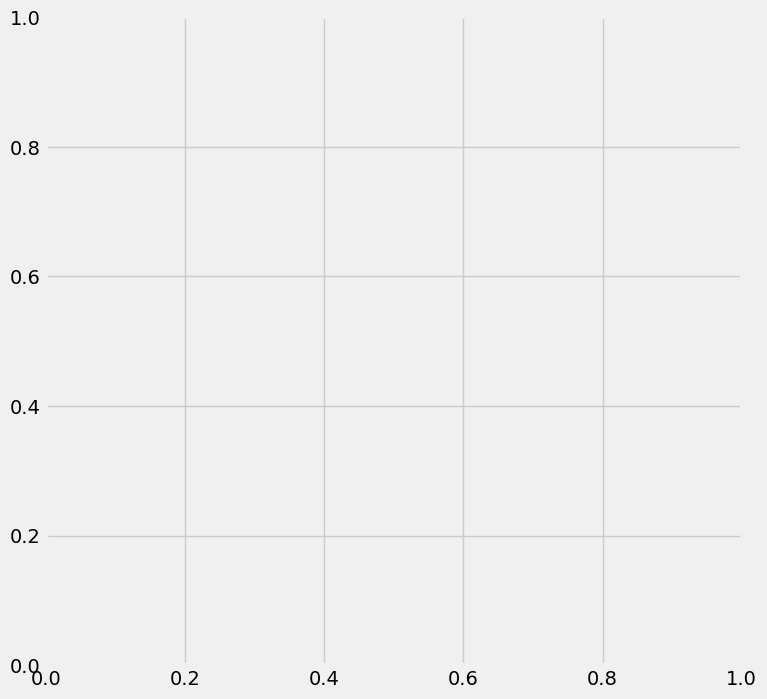

In [40]:
df_preds = pd.DataFrame([logistics_uplift_estimates.ravel(),
                         y_pred_tree.ravel(),
                         y_pred_forest.ravel(),
                         y_preds_t10.ravel(),
                         y_preds_t15.ravel(),
                         treatments,
                         df_test['conversion'].ravel()],
                        index=['logisticsRegression','Tree','Forest','top10feature','top15feature','is_treated', 'conversion']).T



AssertionError: conversion and is_treated, or tau should be present without null.

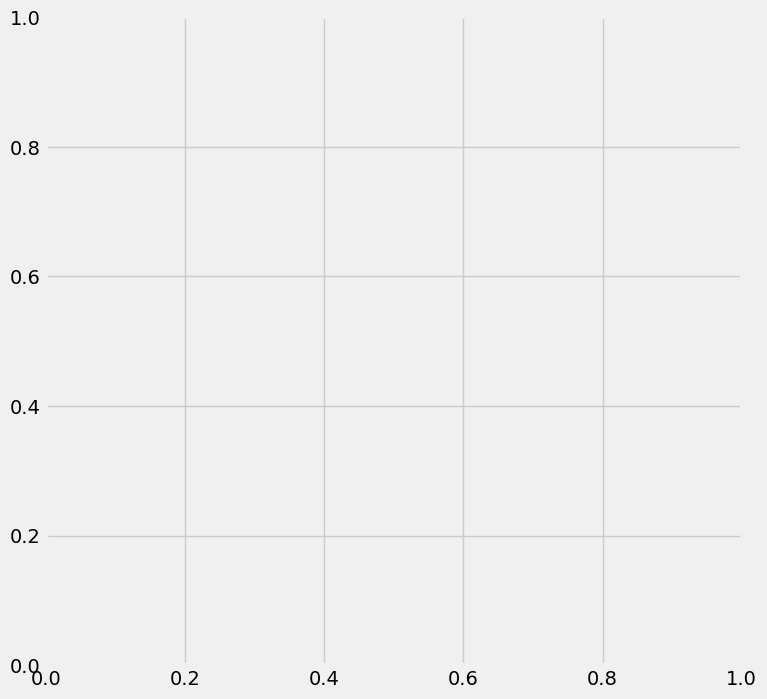

In [41]:
plot_gain(df_preds, outcome_col='conversion', treatment_col='is_treated')

In [ ]:
auuc_score(df_preds, outcome_col='conversion', treatment_col='is_treated')